In [ ]:
import torch
from transformers import MusicgenForConditionalGeneration, AutoProcessor
import utils
import random
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the model and processor
# (musicgen-small works great for extracting attention weights without using too much VRAM)
processor = AutoProcessor.from_pretrained("facebook/musicgen-small")
model = MusicgenForConditionalGeneration.from_pretrained(
    "facebook/musicgen-small",
    attn_implementation="eager"
    )
model.eval()

# 2. Define audio file paths
audio_paths = [
    # "../music-clips/classical_8.wav",
    "../music-clips/classical_1.wav",
    "../music-clips/classical_2.wav",
    # "../music-clips/classical_6.wav",
    "../music-clips/electronic_1.wav",
    # "../music-clips/electronic_10.wav",
    # "../music-clips/electronic_14.wav",
    "../music-clips/electronic_3.wav",
]
wfs = utils.load_process_bulk_audio(audio_paths, sr=32000)
inputs_dict = utils.process_bulk_music_gen(wfs, processor=processor)

# 2. Define the Shuffling Hook
def shuffle_pos_embed_hook(module, input, output):
    """
    output shape from pos_conv_embed: [batch_size, seq_len, hidden_dim]
    """
    seq_len = output.shape[0]
    
    #### Generate a random permutation of temporal indices ######
    permuted_indices = torch.randperm(seq_len)
    # Shuffle positional embeddings along the time (seq_len) dimension
    shuffled_output = output[permuted_indices, :]
    ###################

    ###### Generate chunked permutation #######
    chunks = torch.split(output, split_size_or_sections=10, dim=1)
    # Shuffle the chunk indices
    indices = torch.randperm(len(chunks))
    # Concatenate back together along Axis 1
    shuffled_output = torch.cat([chunks[i] for i in indices], dim=1)
    #################

    return shuffled_output

# 3. Register the hook on the decoder
target_layer = model.decoder.model.decoder.embed_positions
hook_handle = target_layer.register_forward_hook(shuffle_pos_embed_hook)

# 3. Extract attention weights per audio file
attentions_dict_shuffled = {}
attentions_dict_clean = {}
decoder_input_dict = {}
# shuffled pos embeddings
with torch.no_grad():
    for path, inputs in inputs_dict.items():
        # Convert audio to EnCodec tokens (audio codes)
        audio_features = inputs["input_values"]
        decoder_input_ids = model.audio_encoder.encode(audio_features).audio_codes
        decoder_input_dict[path] = decoder_input_ids
        # dummy conditioning: shape must match what the decoder expects
        batch_size = decoder_input_ids.shape[0]
        dummy_encoder_hidden_states = torch.zeros(
            batch_size,
            1,
            1024,  # musicgen-small hidden size
            device=decoder_input_ids.device
        )
        # We must pass the text encoder's hidden states as cross-attention conditioning
        decoder_outputs = model.decoder(
            input_ids=decoder_input_ids,
            encoder_hidden_states=dummy_encoder_hidden_states,  # Map the correct 1024 shape here
            output_attentions=True,
            return_dict=True
        )

        self_attentions = decoder_outputs.attentions
        attentions_dict_shuffled[path] = self_attentions

hook_handle.remove()

# clean pos embeddings
with torch.no_grad():
    for path, inputs in inputs_dict.items():
        audio_features = inputs["input_values"]
        decoder_input_ids = model.audio_encoder.encode(audio_features).audio_codes
        decoder_input_dict[path] = decoder_input_ids
        # dummy conditioning: shape must match what the decoder expects
        batch_size = decoder_input_ids.shape[0]
        dummy_encoder_hidden_states = torch.zeros(
            batch_size,
            1,
            1024,  # musicgen-small hidden size
            device=decoder_input_ids.device
        )
        # We must pass the text encoder's hidden states as cross-attention conditioning
        decoder_outputs = model.decoder(
            input_ids=decoder_input_ids,
            encoder_hidden_states=dummy_encoder_hidden_states,  # Map the correct 1024 shape here
            output_attentions=True,
            return_dict=True
        )

        self_attentions = decoder_outputs.attentions
        attentions_dict_clean[path] = self_attentions

Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]

MusicgenSinusoidalPositionalEmbedding()


In [ ]:
# print(attentions_dict_clean)

mad_dict_clean = {}
mad_dict_shuffled = {}
for path, attn in attentions_dict_clean.items():
    seq_length = attn[0].shape[-1]
    print(path, seq_length)
    mean_distances_clean = utils.compute_mad_by_layer(attn, seq_length)
    mad_dict_clean[path] = mean_distances_clean

    mean_distances_shuffled = utils.compute_mad_by_layer(attentions_dict_shuffled.get(path), seq_length)
    mad_dict_shuffled[path] = mean_distances_shuffled

../music-clips/classical_1.wav 3002
../music-clips/classical_2.wav 3002
../music-clips/electronic_1.wav 3000
../music-clips/electronic_3.wav 3000


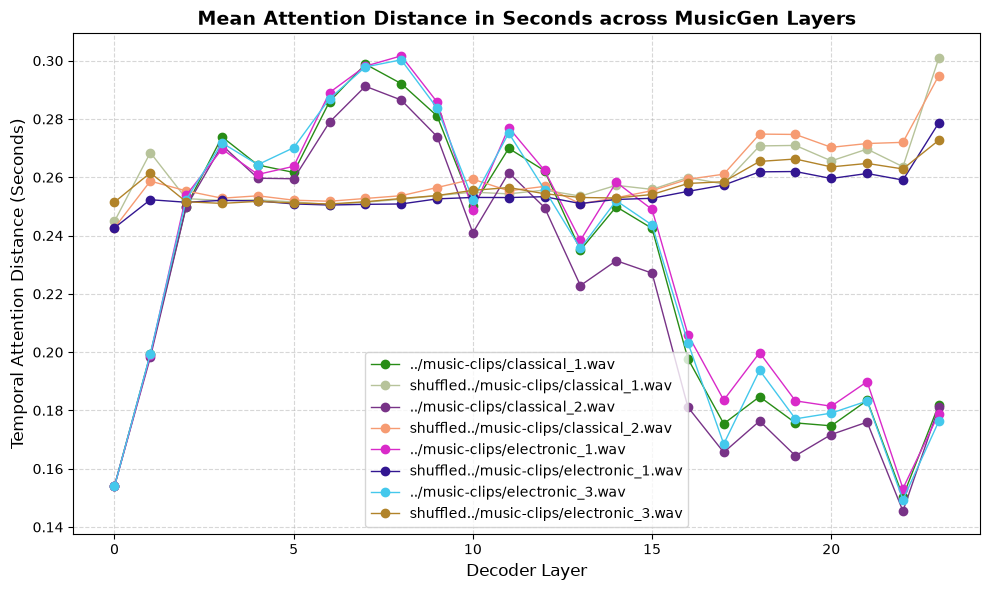

In [ ]:
plt.figure(figsize=(10, 6))

for path, mads in mad_dict_clean.items():
    random_hex = f"#{random.randint(0, 0xFFFFFF):06x}"
    num_layers = len(attentions_dict_clean.get(path))
    layer_averages_clean = np.mean(mads, axis=1)
    layer_averages_shuffled = np.mean(mad_dict_shuffled.get(path), axis=1)
    plt.plot(range(num_layers), layer_averages_clean, color=random_hex, linewidth=1, marker='o', label=path)
    plt.plot(range(num_layers), layer_averages_shuffled, color=f"#{random.randint(0, 0xFFFFFF):06x}", linewidth=1, marker='o', label='shuffled' + path)

plt.title("Mean Attention Distance Percentage across MusicGen Layers", fontsize=14, fontweight='bold')
plt.xlabel("Layer", fontsize=12)
plt.ylabel("Temporal Attention Distance (Percentage of Clip)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()